In [29]:
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 한글 깨짐 방지(Colab)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [30]:
from pathlib import Path

candidate_paths = [
    Path("../data/fraudTrain.csv"),
    Path("data/fraudTrain.csv"),
    Path("../../data/fraudTrain.csv"),
    Path("fraudTrain.csv.zip"),
    Path("fraudTrain.csv"),
]

train_path = next((p for p in candidate_paths if p.exists()), None)

if train_path is None:
    print("cwd:", Path.cwd())
    raise FileNotFoundError("fraudTrain.csv(.zip)를 찾지 못함")

df = pd.read_csv(train_path)


In [31]:
# 1. 결측치 확인
df.isnull().sum()

# 2. 중복 확인
df.duplicated().sum()

# 3. 자료형 확인
df.info()

# 4. 날짜형 변환
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [32]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [33]:
df.info()  #데이터 타입 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Unnamed: 0             1296675 non-null  int64         
 1   trans_date_trans_time  1296675 non-null  datetime64[ns]
 2   cc_num                 1296675 non-null  int64         
 3   merchant               1296675 non-null  object        
 4   category               1296675 non-null  object        
 5   amt                    1296675 non-null  float64       
 6   first                  1296675 non-null  object        
 7   last                   1296675 non-null  object        
 8   gender                 1296675 non-null  object        
 9   street                 1296675 non-null  object        
 10  city                   1296675 non-null  object        
 11  state                  1296675 non-null  object        
 12  zip                    12966

In [34]:
print(df.columns) #컬럼명 확인

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')


In [35]:
num_cols = [
    'amt',
    'city_pop',
    'lat',
    'long',
    'merch_lat',
    'merch_long'
]

df[num_cols].describe().T.round(2) ###수치형 변수 기술통계

,count,mean,std,min,25%,50%,75%,max
amt,1296675.0,70.35,160.32,1.00,9.65,47.52,83.14,28948.90
city_pop,1296675.0,88824.44,301956.36,23.00,743.00,2456.00,20328.00,2906700.00
lat,1296675.0,38.54,5.08,20.03,34.62,39.35,41.94,66.69
long,1296675.0,-90.23,13.76,-165.67,-96.80,-87.48,-80.16,-67.95
merch_lat,1296675.0,38.54,5.11,19.03,34.73,39.37,41.96,67.51
merch_long,1296675.0,-90.23,13.77,-166.67,-96.90,-87.44,-80.24,-66.95


In [36]:
cat_cols = [
    'merchant',
    'category',
    'gender',
    'city',
    'state',
    'job'
]

df[cat_cols].describe().T    ###범주형 기술통계

,count,unique,top,freq
merchant,1296675,693,fraud_Kilback LLC,4403
category,1296675,14,gas_transport,131659
gender,1296675,2,F,709863
city,1296675,894,Birmingham,5617
state,1296675,51,TX,94876
job,1296675,494,Film/video editor,9779


In [37]:
df.dtypes

Unnamed: 0                        int64
trans_date_trans_time    datetime64[ns]
cc_num                            int64
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
gender                           object
street                           object
city                             object
state                            object
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                      datetime64[ns]
trans_num                        object
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
dtype: object

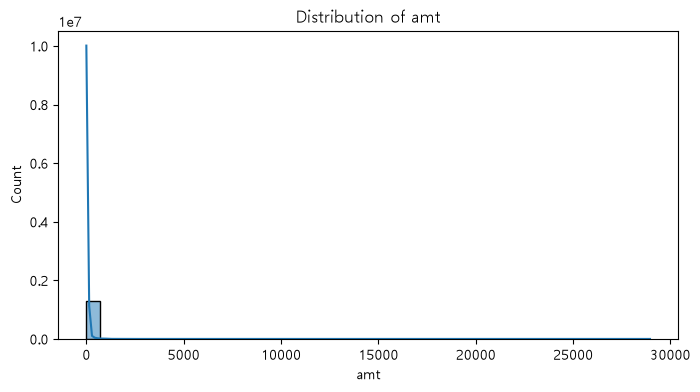

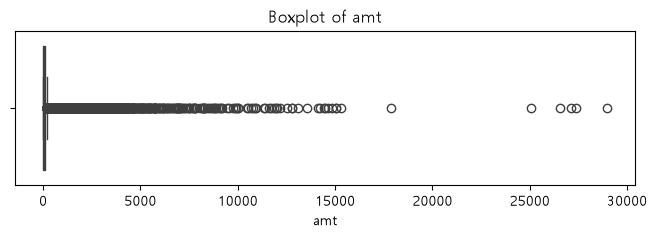

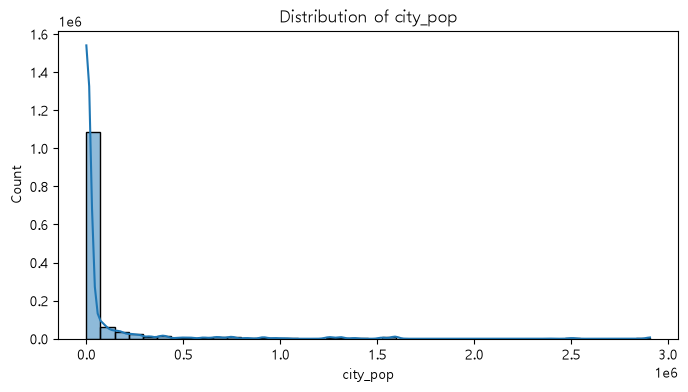

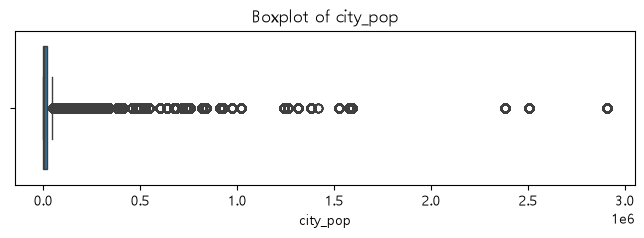

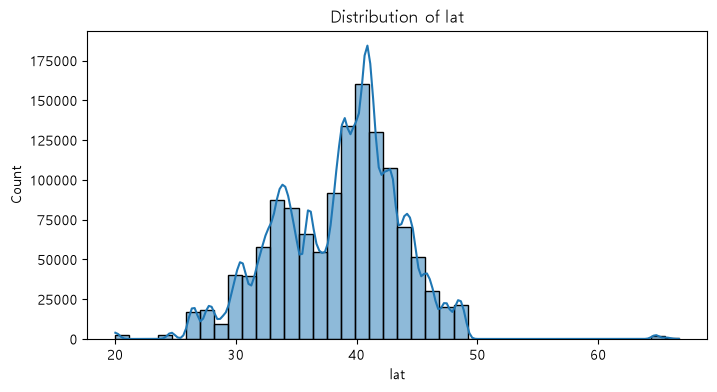

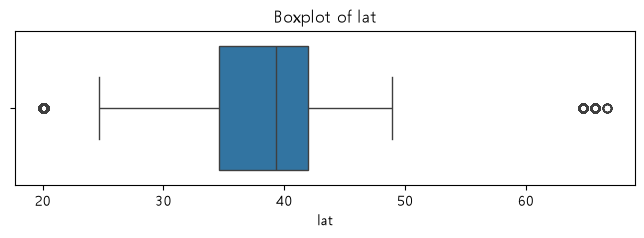

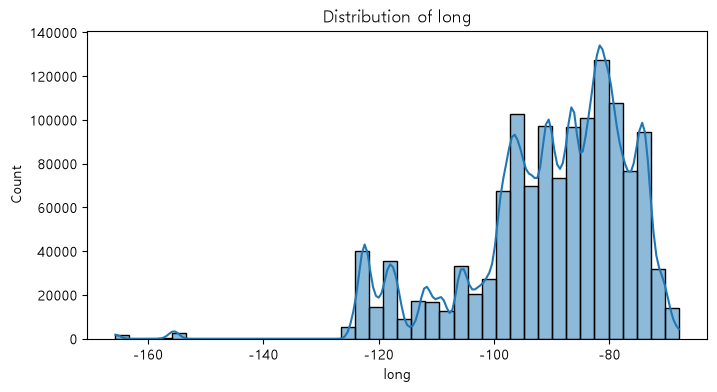

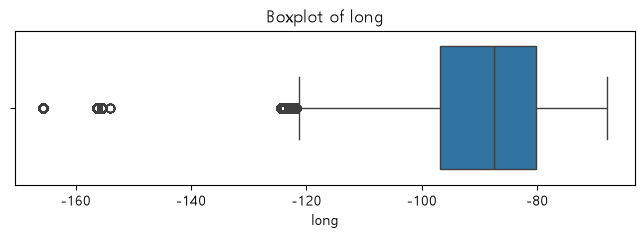

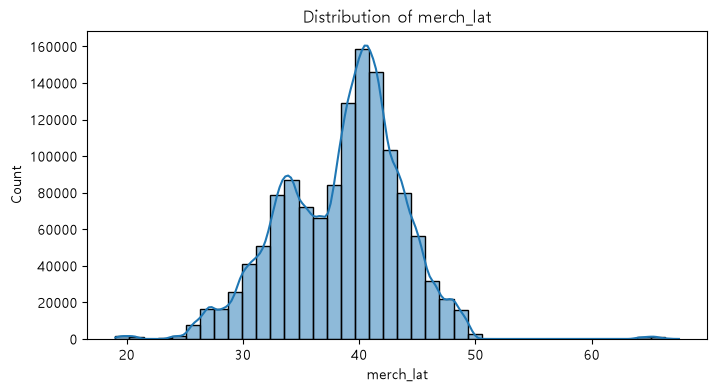

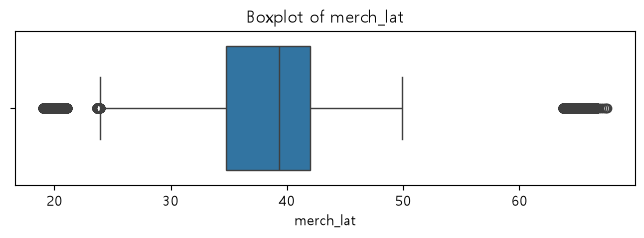

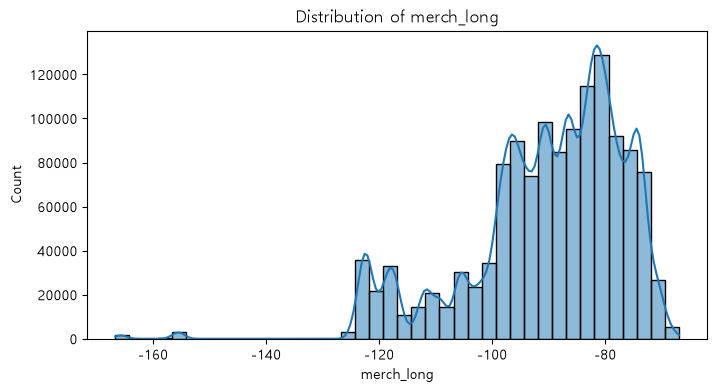

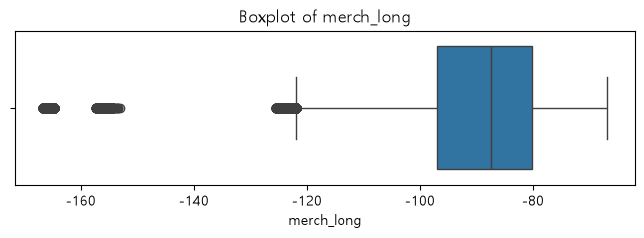

In [38]:
######수치형변수 시각화코드
num_cols = [
    'amt',
    'city_pop',
    'lat',
    'long',
    'merch_lat',
    'merch_long'
]

for col in num_cols:

    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=40, kde=True)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    plt.show()

    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

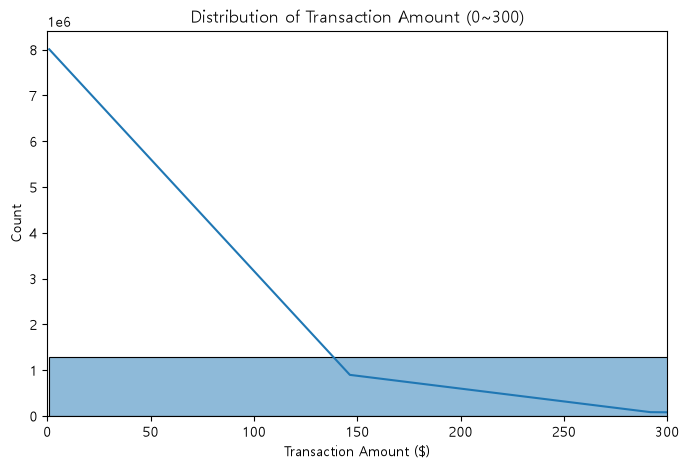

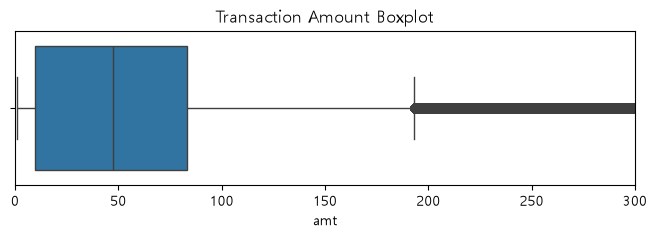

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df['amt'], bins=50, kde=True)

plt.xlim(0,300)

plt.title('Distribution of Transaction Amount (0~300)')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Count')

plt.show()

plt.figure(figsize=(8,2))

sns.boxplot(x=df['amt'])

plt.xlim(0,300)

plt.title('Transaction Amount Boxplot')

plt.show()

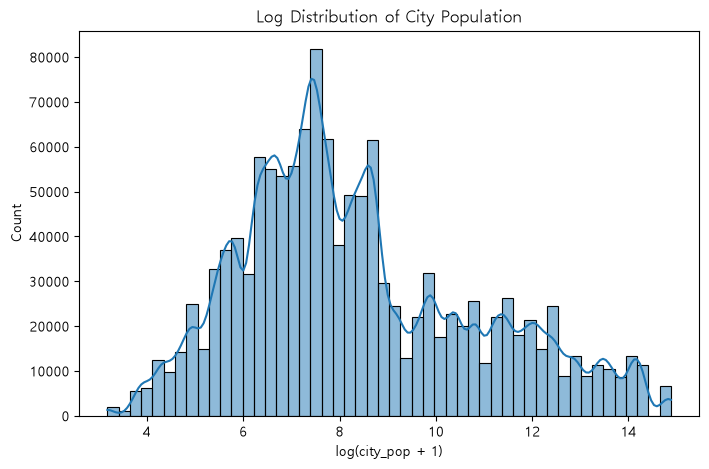

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df['city_pop']), bins=50, kde=True)

plt.title('Log Distribution of City Population')
plt.xlabel('log(city_pop + 1)')

plt.show()

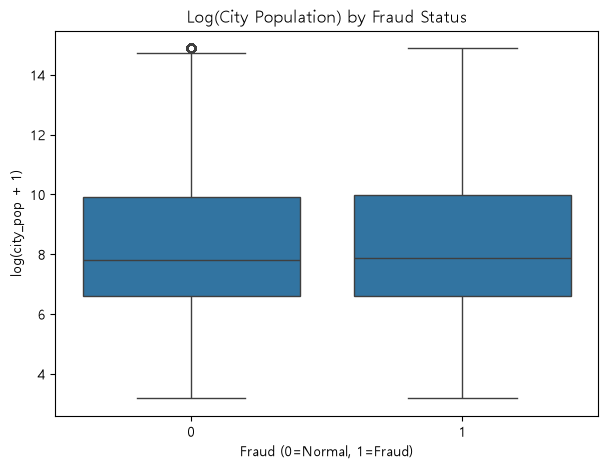

In [41]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='is_fraud',
    y=np.log1p(df['city_pop'])
)

plt.title('Log(City Population) by Fraud Status')
plt.xlabel('Fraud (0=Normal, 1=Fraud)')
plt.ylabel('log(city_pop + 1)')

plt.show()

In [42]:
df = df.sort_values(['cc_num','trans_date_trans_time'])

df['time_diff_sec'] = (
    df.groupby('cc_num')['trans_date_trans_time']
      .diff()
      .dt.total_seconds()
)

In [43]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2-lat1
    dlon = lon2-lon1

    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2

    c = 2*atan2(sqrt(a), sqrt(1-a))

    return R*c

df['distance_km'] = df.apply(
    lambda x: haversine(
        x['lat'],
        x['long'],
        x['merch_lat'],
        x['merch_long']
    ),
    axis=1
)

In [44]:
df = df.sort_values(['cc_num', 'trans_date_trans_time'])

df['prev_lat'] = df.groupby('cc_num')['merch_lat'].shift(1)
df['prev_long'] = df.groupby('cc_num')['merch_long'].shift(1)

df['move_distance_km'] = df.apply(
    lambda x: haversine(
        x['prev_lat'],
        x['prev_long'],
        x['merch_lat'],
        x['merch_long']
    ) if pd.notnull(x['prev_lat']) else np.nan,
    axis=1
)

In [45]:
###########수정 코드
df['speed_kmh'] = np.where(
    df['time_diff_sec'] > 0,
    df['move_distance_km'] / (df['time_diff_sec']/3600),
    np.nan
)

In [46]:
df[['cc_num','move_distance_km']].head()

,cc_num,move_distance_km
1017,60416207185,NaN
2724,60416207185,224.769219
2726,60416207185,105.220439
2882,60416207185,88.152283
2907,60416207185,132.876773


In [47]:
#!pip install haversine

In [48]:
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):

    R = 6371.0

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

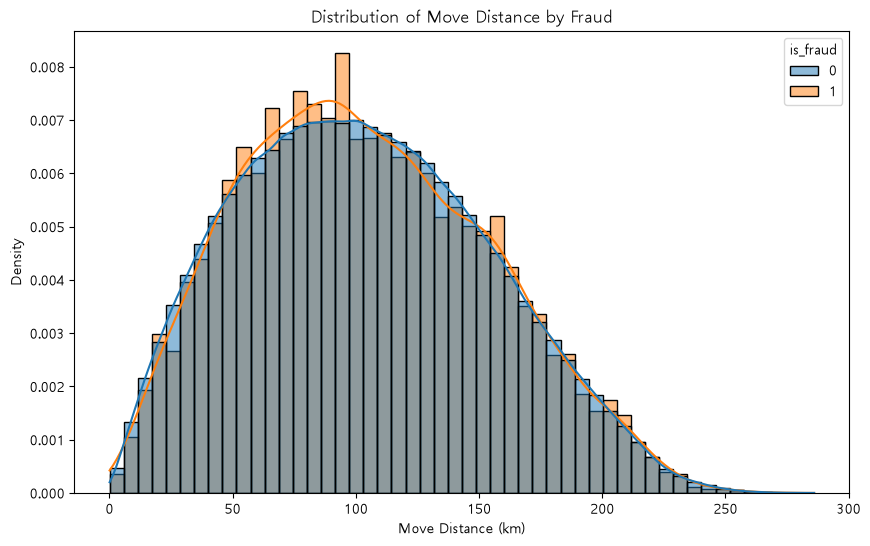

In [49]:
####파생변수 시각화 코드

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='move_distance_km',
    hue='is_fraud',
    bins=50,
    kde=True,
    stat='density',
    common_norm=False,
    alpha=0.5
)

plt.xlabel('Move Distance (km)')
plt.title('Distribution of Move Distance by Fraud')

plt.show()

In [50]:
import numpy as np
import pandas as pd

# 날짜형 변환
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# 정렬
df = df.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)

# 결과 저장
df['count_30min'] = 0

# 카드별 계산
for cc_num, idx in df.groupby('cc_num').groups.items():

    times = df.loc[idx, 'trans_date_trans_time'].values.astype('datetime64[s]')

    left = np.searchsorted(
        times,
        times - np.timedelta64(30, 'm')
    )

    right = np.arange(len(times))

    df.loc[idx, 'count_30min'] = right - left + 1



In [51]:
df['count_30min'].value_counts().sort_index().head(20)

count_30min
1    1182226
2     105948
3       7820
4        630
5         50
6          1
Name: count, dtype: int64

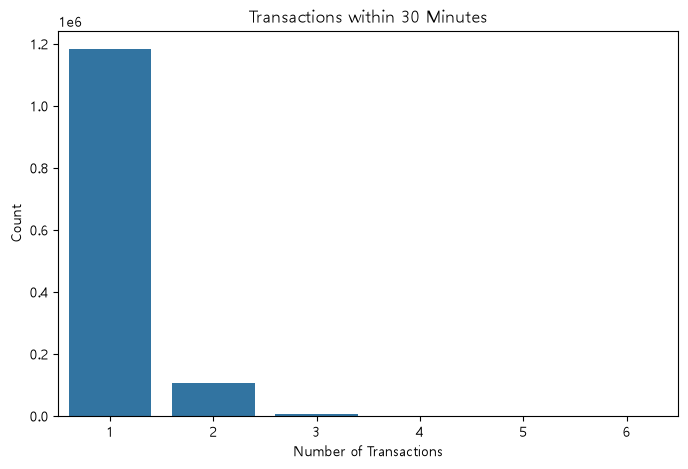

In [52]:
plt.figure(figsize=(8,5))

order = sorted(df['count_30min'].unique())

sns.countplot(
    data=df,
    x='count_30min',
    order=order
)

plt.title('Transactions within 30 Minutes')
plt.xlabel('Number of Transactions')
plt.ylabel('Count')

plt.show()

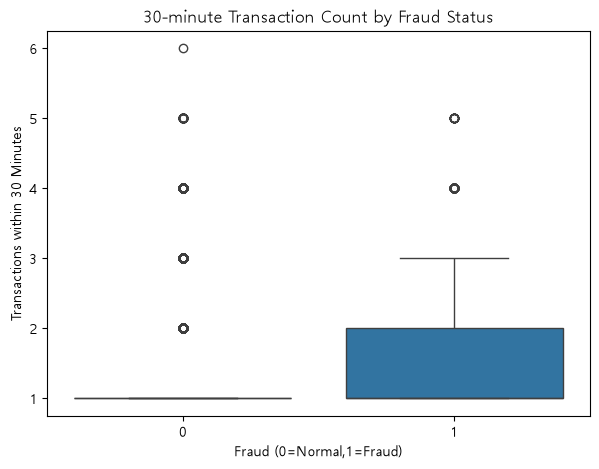

In [53]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='is_fraud',
    y='count_30min'
)

plt.title('30-minute Transaction Count by Fraud Status')
plt.xlabel('Fraud (0=Normal,1=Fraud)')
plt.ylabel('Transactions within 30 Minutes')

plt.show()

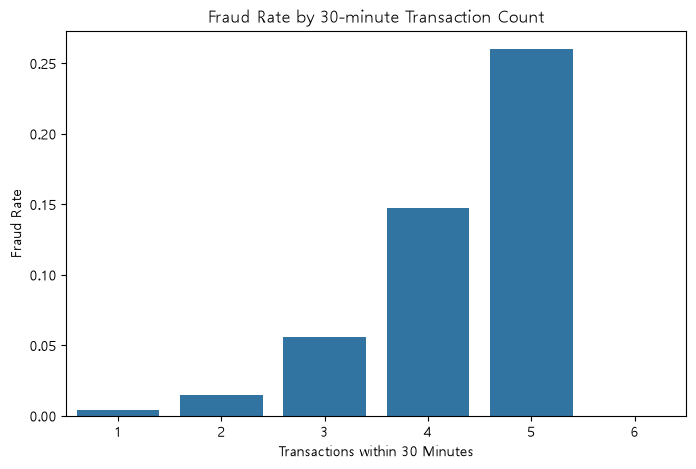

In [54]:
fraud_rate = (
    df.groupby('count_30min')['is_fraud']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=fraud_rate,
    x='count_30min',
    y='is_fraud'
)

plt.title("Fraud Rate by 30-minute Transaction Count")
plt.xlabel("Transactions within 30 Minutes")
plt.ylabel("Fraud Rate")

plt.show()

In [55]:
#거래건수+사기율
summary = (
    df.groupby('count_30min')
      .agg(
          transaction_count=('is_fraud', 'count'),
          fraud_count=('is_fraud', 'sum'),
          fraud_rate=('is_fraud', 'mean')
      )
)

print(summary)

             transaction_count  fraud_count  fraud_rate
count_30min                                            
1                      1182226         5351    0.004526
2                       105948         1610    0.015196
3                         7820          439    0.056138
4                          630           93    0.147619
5                           50           13    0.260000
6                            1            0    0.000000


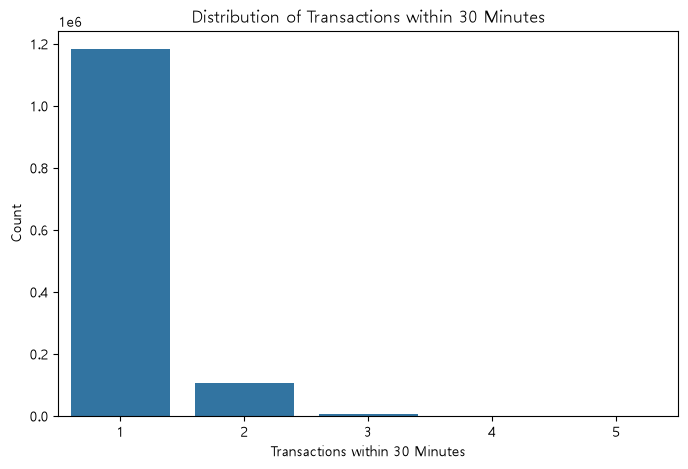

In [56]:
##거래횟수
plt.figure(figsize=(8,5))

sns.countplot(
    data=df[df['count_30min'] <= 5],
    x='count_30min'
)

plt.title('Distribution of Transactions within 30 Minutes')
plt.xlabel('Transactions within 30 Minutes')
plt.ylabel('Count')

plt.show()

In [57]:
df['count_30min'].value_counts().sort_index()

count_30min
1    1182226
2     105948
3       7820
4        630
5         50
6          1
Name: count, dtype: int64

In [58]:
df = df.sort_values(['cc_num','trans_date_trans_time'])

df['time_diff_sec'] = (
    df.groupby('cc_num')['trans_date_trans_time']
      .diff()
      .dt.total_seconds()
)


In [59]:
print(df['trans_date_trans_time'].dtype)

datetime64[ns]


In [60]:
df.groupby('is_fraud')['time_diff_sec'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1288261.0,32549.396663,47449.270430,0.0,6064.0,16623.0,40262.0,1341471.0
1,7431.0,21323.662630,36436.695488,1.0,1473.0,4908.0,28974.5,865077.0


In [61]:
df['time_diff_sec'].describe()

count    1.295692e+06
mean     3.248502e+04
std      4.740098e+04
min      0.000000e+00
25%      6.013000e+03
50%      1.656000e+04
75%      4.022300e+04
max      1.341471e+06
Name: time_diff_sec, dtype: float64

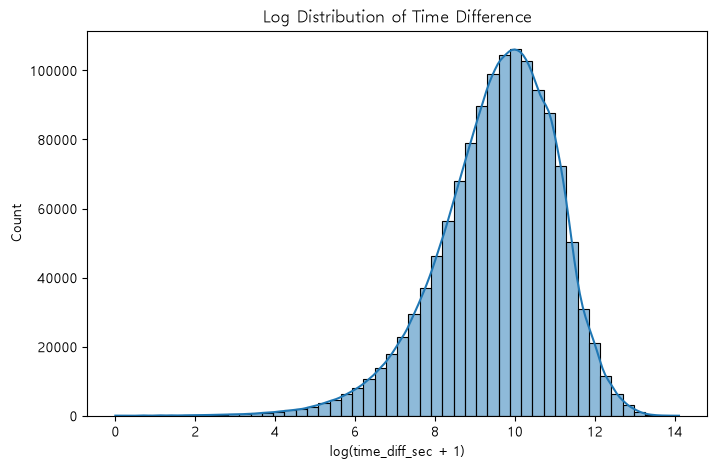

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(df['time_diff_sec'].dropna()),
    bins=50,
    kde=True
)

plt.title('Log Distribution of Time Difference')
plt.xlabel('log(time_diff_sec + 1)')

plt.show()

In [63]:
# 온라인 거래 제거
offline_df = df[~df['category'].isin(['shopping_net', 'misc_net'])].copy()

print(offline_df.shape)
offline_df['category'].value_counts()

offline_df = offline_df.sort_values(
    ['cc_num', 'trans_date_trans_time']
)

offline_df['prev_lat'] = (
    offline_df.groupby('cc_num')['merch_lat']
    .shift(1)
)

offline_df['prev_long'] = (
    offline_df.groupby('cc_num')['merch_long']
    .shift(1)
)

offline_df['move_distance_km'] = offline_df.apply(
    lambda x: haversine_distance(
        x['prev_lat'],
        x['prev_long'],
        x['merch_lat'],
        x['merch_long']
    )
    if pd.notnull(x['prev_lat']) else np.nan,
    axis=1
)

offline_df['time_diff_sec'] = (
    offline_df.groupby('cc_num')['trans_date_trans_time']
    .diff()
    .dt.total_seconds()
)
offline_df['speed_kmh'] = np.where(
    offline_df['time_diff_sec'] > 0,
    offline_df['move_distance_km'] / (offline_df['time_diff_sec'] / 3600),
    np.nan
)


(1135845, 30)


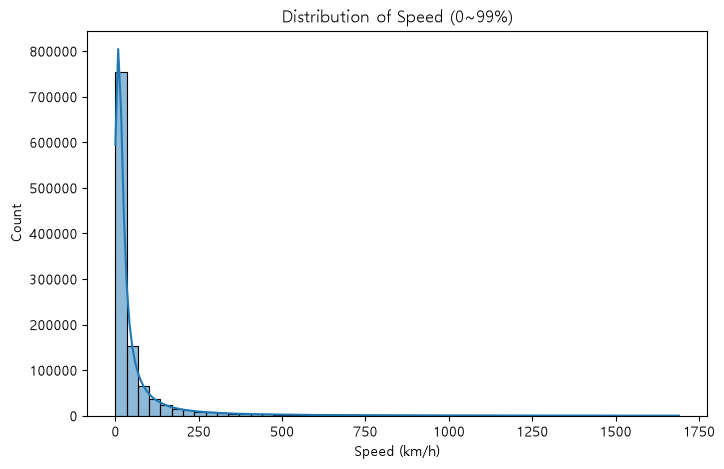

In [64]:
##이동속도
import matplotlib.pyplot as plt
import seaborn as sns

speed = offline_df['speed_kmh'].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(8,5))

sns.histplot(
    speed[speed <= speed.quantile(0.99)],
    bins=50,
    kde=True
)

plt.title('Distribution of Speed (0~99%)')
plt.xlabel('Speed (km/h)')
plt.ylabel('Count')

plt.show()

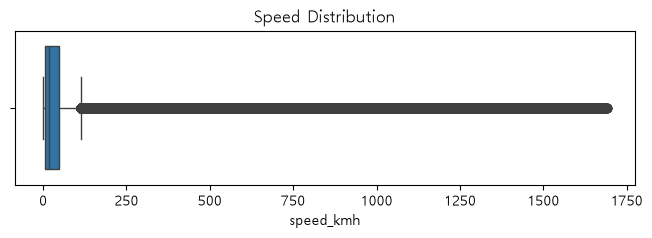

In [65]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=speed[speed <= speed.quantile(0.99)]
)

plt.title("Speed Distribution")

plt.show()

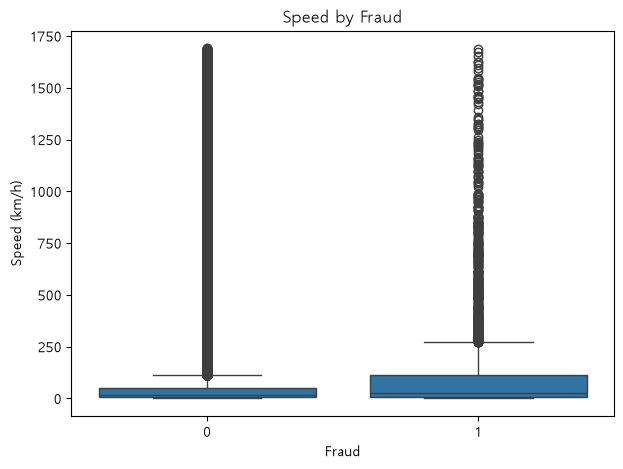

In [66]:
plot_df = offline_df.copy()

plot_df['speed_kmh'] = plot_df['speed_kmh'].replace([np.inf, -np.inf], np.nan)

plot_df = plot_df[
    plot_df['speed_kmh'] <= plot_df['speed_kmh'].quantile(0.99)
]

plt.figure(figsize=(7,5))

sns.boxplot(
    data=plot_df,
    x='is_fraud',
    y='speed_kmh'
)

plt.title("Speed by Fraud")
plt.xlabel("Fraud")
plt.ylabel("Speed (km/h)")

plt.show()

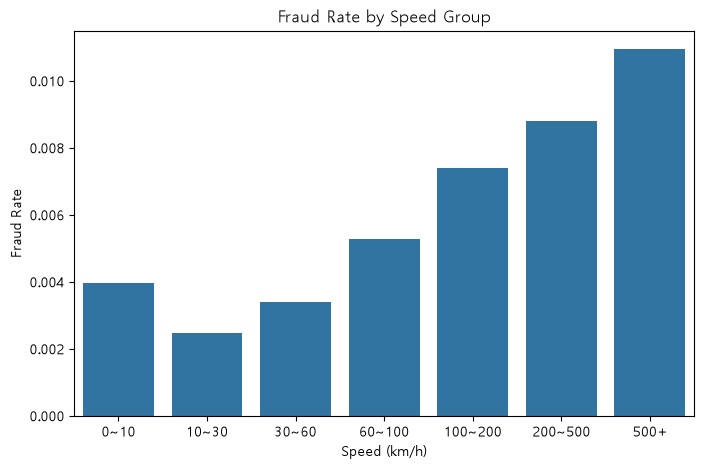

In [67]:
speed_df = offline_df.copy()

speed_df = speed_df.replace([np.inf, -np.inf], np.nan)
speed_df = speed_df.dropna(subset=['speed_kmh'])

bins = [0, 10, 30, 60, 100, 200, 500, speed_df['speed_kmh'].max()]
labels = ['0~10', '10~30', '30~60', '60~100', '100~200', '200~500', '500+']

speed_df['speed_group'] = pd.cut(
    speed_df['speed_kmh'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

fraud_rate = (
    speed_df.groupby('speed_group', observed=False)['is_fraud']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=fraud_rate,
    x='speed_group',
    y='is_fraud'
)

plt.title("Fraud Rate by Speed Group")
plt.xlabel("Speed (km/h)")
plt.ylabel("Fraud Rate")

plt.show()

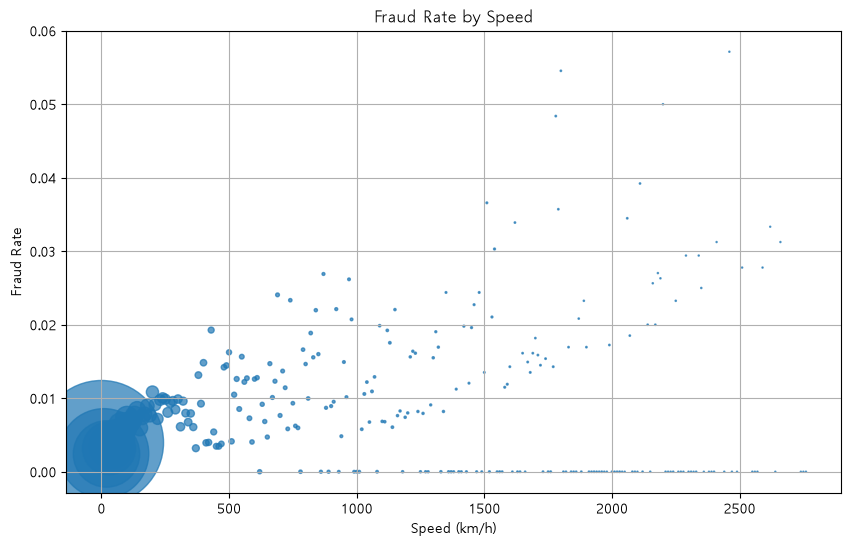

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

speed_df = offline_df.copy()

# inf 제거
speed_df = speed_df.replace([np.inf, -np.inf], np.nan)
speed_df = speed_df.dropna(subset=['speed_kmh'])

# 이동속도를 10km/h 단위로 구간화
speed_df['speed_bin'] = (speed_df['speed_kmh'] // 10) * 10

fraud_rate = (
    speed_df
    .groupby('speed_bin')
    .agg(
        fraud_rate=('is_fraud', 'mean'),
        transaction_count=('is_fraud', 'count')
    )
    .reset_index()
)

# 거래가 너무 적은 구간 제거(예: 30건 미만)
fraud_rate = fraud_rate[fraud_rate['transaction_count'] >= 30]

plt.figure(figsize=(10,6))

plt.scatter(
    fraud_rate['speed_bin'],
    fraud_rate['fraud_rate'],
    s=fraud_rate['transaction_count']/50,   # 거래량에 따라 점 크기
    alpha=0.7
)

plt.xlabel("Speed (km/h)")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Speed")

plt.grid(True)

plt.show()

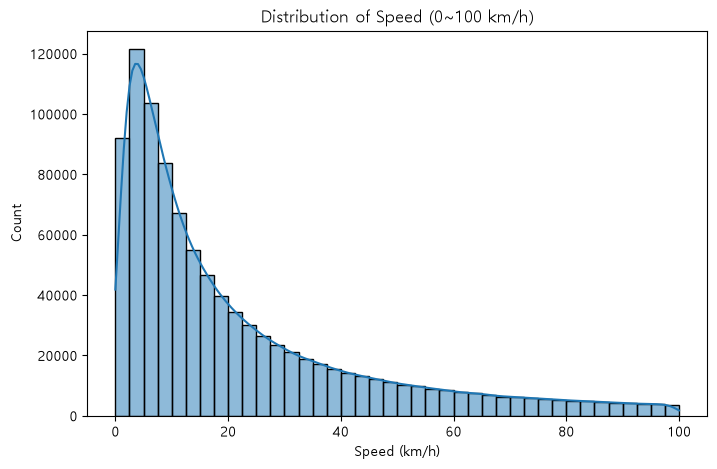

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

speed_df = offline_df.copy()

# inf 제거
speed_df['speed_kmh'] = speed_df['speed_kmh'].replace([np.inf, -np.inf], np.nan)

# 0~100km/h만 선택
speed_plot = speed_df[
    (speed_df['speed_kmh'] >= 0) &
    (speed_df['speed_kmh'] <= 100)
]

plt.figure(figsize=(8,5))

sns.histplot(
    speed_plot['speed_kmh'],
    bins=40,
    kde=True
)

plt.xlabel("Speed (km/h)")
plt.ylabel("Count")
plt.title("Distribution of Speed (0~100 km/h)")

plt.show()

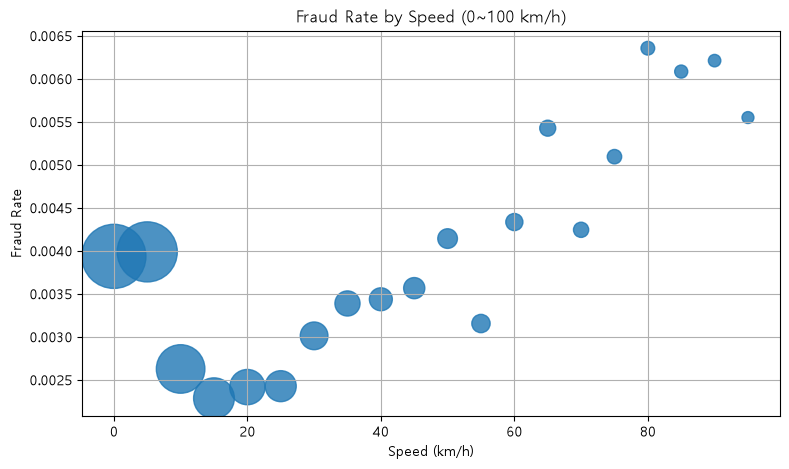

In [70]:
plot_df = speed_plot.copy()

# 5km/h 단위 구간
plot_df['speed_bin'] = (plot_df['speed_kmh'] // 5) * 5

fraud_rate = (
    plot_df
    .groupby('speed_bin')
    .agg(
        fraud_rate=('is_fraud','mean'),
        transaction_count=('is_fraud','count')
    )
    .reset_index()
)

# 거래건수가 너무 적은 구간 제거
fraud_rate = fraud_rate[
    fraud_rate['transaction_count'] >= 30
]

plt.figure(figsize=(9,5))

plt.scatter(
    fraud_rate['speed_bin'],
    fraud_rate['fraud_rate'],
    s=fraud_rate['transaction_count']/100,
    alpha=0.8
)

plt.xlabel("Speed (km/h)")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Speed (0~100 km/h)")

plt.grid(True)

plt.show()

   speed_group  transaction_count  fraud_count  fraud_rate
0     ≤10 km/h             400680         1586    0.003958
1  10~100 km/h             569185         1792    0.003148
2    >100 km/h             164981         1425    0.008637


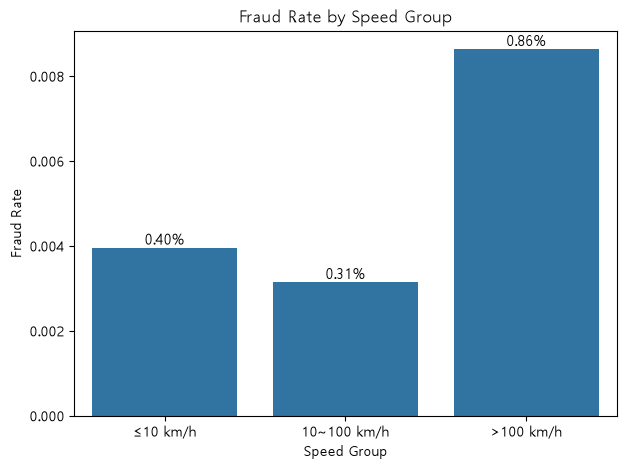

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = offline_df.copy()

# inf 제거
plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
plot_df = plot_df.dropna(subset=['speed_kmh'])

# 속도 구간 생성
plot_df['speed_group'] = pd.cut(
    plot_df['speed_kmh'],
    bins=[0, 10, 100, np.inf],
    labels=['≤10 km/h', '10~100 km/h', '>100 km/h'],
    include_lowest=True
)

# 사기율 계산
result = (
    plot_df.groupby('speed_group', observed=False)
    .agg(
        transaction_count=('is_fraud','count'),
        fraud_count=('is_fraud','sum'),
        fraud_rate=('is_fraud','mean')
    )
    .reset_index()
)

print(result)

# 시각화
plt.figure(figsize=(7,5))

sns.barplot(
    data=result,
    x='speed_group',
    y='fraud_rate'
)

# 막대 위에 사기율 표시
for i, rate in enumerate(result['fraud_rate']):
    plt.text(i, rate, f"{rate:.2%}", ha='center', va='bottom', fontsize=11)

plt.xlabel("Speed Group")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Speed Group")

plt.show()

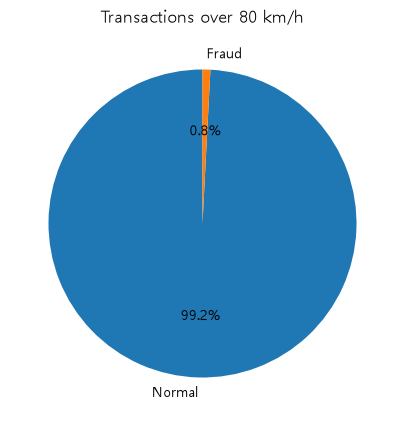

In [72]:
speed80 = offline_df[
    (offline_df['speed_kmh'] >= 80) &
    (offline_df['speed_kmh'] != np.inf)
].copy()

count_df = (
    speed80['is_fraud']
    .value_counts()
    .rename(index={0:'Normal', 1:'Fraud'})
)

plt.figure(figsize=(5,5))

plt.pie(
    count_df,
    labels=count_df.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Transactions over 80 km/h')

plt.show()

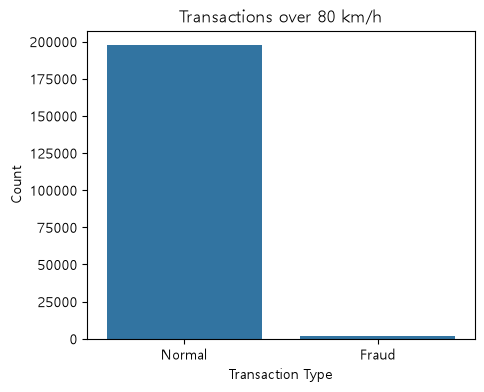

In [73]:
count_df = (
    speed80['is_fraud']
    .value_counts()
    .rename(index={0:'Normal',1:'Fraud'})
)

plt.figure(figsize=(5,4))

sns.barplot(
    x=count_df.index,
    y=count_df.values
)

plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.title("Transactions over 80 km/h")

plt.show()

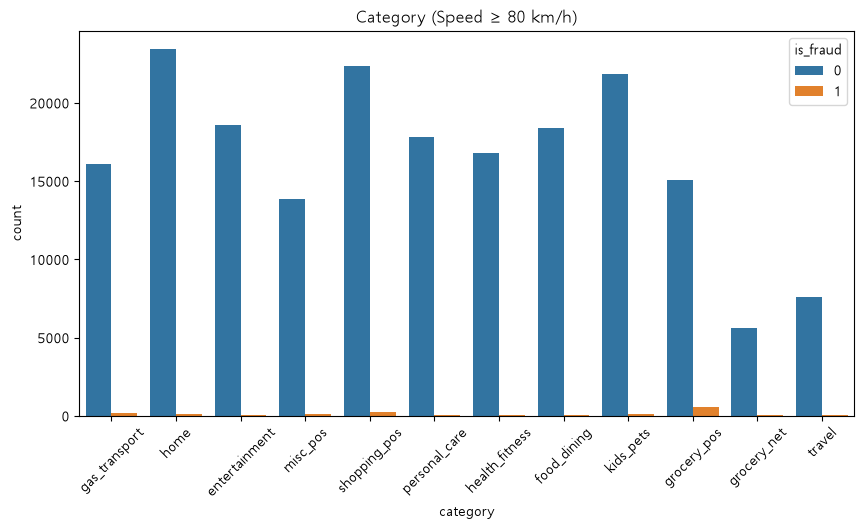

In [74]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=speed80,
    x='category',
    hue='is_fraud'
)

plt.xticks(rotation=45)

plt.title("Category (Speed ≥ 80 km/h)")

plt.show()

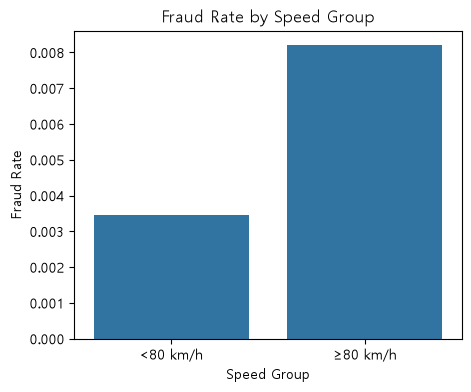

  speed_group  transaction_count  fraud_count  fraud_rate
0    <80 km/h             936782         3246    0.003465
1    ≥80 km/h             199063         1632    0.008198


In [75]:
compare = offline_df.copy()

compare['speed_group'] = np.where(
    compare['speed_kmh'] >= 80,
    '≥80 km/h',
    '<80 km/h'
)

result = (
    compare.groupby('speed_group')
    .agg(
        transaction_count=('is_fraud','count'),
        fraud_count=('is_fraud','sum'),
        fraud_rate=('is_fraud','mean')
    )
    .reset_index()
)

plt.figure(figsize=(5,4))

sns.barplot(
    data=result,
    x='speed_group',
    y='fraud_rate'
)

plt.ylabel("Fraud Rate")
plt.xlabel("Speed Group")
plt.title("Fraud Rate by Speed Group")

plt.show()

print(result)

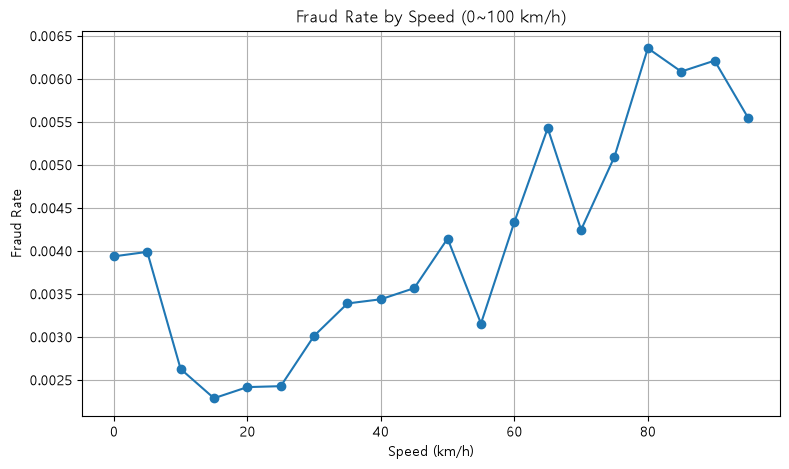

In [76]:
plt.figure(figsize=(9,5))

plt.plot(
    fraud_rate['speed_bin'],
    fraud_rate['fraud_rate'],
    marker='o'
)

plt.xlabel("Speed (km/h)")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Speed (0~100 km/h)")

plt.grid(True)

plt.show()

In [77]:
speed70 = speed_df[speed_df['speed_kmh'] >= 70]

print("거래건수 :", len(speed70))
print("사기건수 :", speed70['is_fraud'].sum())
print("사기율 :", speed70['is_fraud'].mean())

거래건수 : 221884
사기건수 : 1738
사기율 : 0.007832921706837807


In [78]:
result = (
    speed_df.assign(
        speed_group=np.where(
            speed_df['speed_kmh'] >= 70,
            '70km/h 이상',
            '70km/h 미만'
        )
    )
    .groupby('speed_group')
    .agg(
        transaction_count=('is_fraud','count'),
        fraud_count=('is_fraud','sum'),
        fraud_rate=('is_fraud','mean')
    )
)

print(result)

             transaction_count  fraud_count  fraud_rate
speed_group                                            
70km/h 미만               913961         3140    0.003436
70km/h 이상               221884         1738    0.007833


In [79]:
# 이동거리 구간 생성
bins = [0, 10, 30, 50, 100, 300, 500, 1000]

df['distance_group'] = pd.cut(
    df['move_distance_km'],
    bins=bins
)

distance_fraud = (
    df.groupby('distance_group', observed=False)
      .agg(
          transaction_count=('is_fraud','count'),
          fraud_count=('is_fraud','sum'),
          fraud_rate=('is_fraud','mean')
      )
      .reset_index()
)

distance_fraud


,distance_group,transaction_count,fraud_count,fraud_rate
0,"(0, 10]",10239,44,0.004297
1,"(10, 30]",72995,368,0.005041
2,"(30, 50]",126614,707,0.005584
3,"(50, 100]",430877,2615,0.006069
4,"(100, 300]",654967,3697,0.005645
5,"(300, 500]",0,0,NaN
6,"(500, 1000]",0,0,NaN


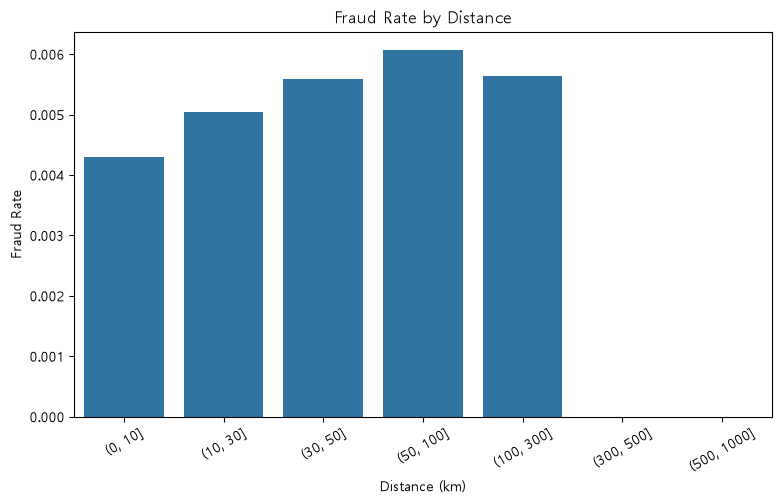

In [80]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=distance_fraud,
    x='distance_group',
    y='fraud_rate'
)

plt.title("Fraud Rate by Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=30)

plt.show()

In [81]:
bins = [0, 10, 30, 60, 100, 200, 500, 1000]

offline_df['speed_group'] = pd.cut(
    offline_df['speed_kmh'],
    bins=bins
)

speed_fraud = (
    offline_df.groupby('speed_group', observed=False)
      .agg(
          transaction_count=('is_fraud','count'),
          fraud_count=('is_fraud','sum'),
          fraud_rate=('is_fraud','mean')
      )
      .reset_index()
)

speed_fraud


,speed_group,transaction_count,fraud_count,fraud_rate
0,"(0, 10]",400680,1586,0.003958
1,"(10, 30]",322997,795,0.002461
2,"(30, 60]",160777,546,0.003396
3,"(60, 100]",85411,451,0.005280
4,"(100, 200]",76049,562,0.007390
5,"(200, 500]",51567,454,0.008804
6,"(500, 1000]",18255,200,0.010956


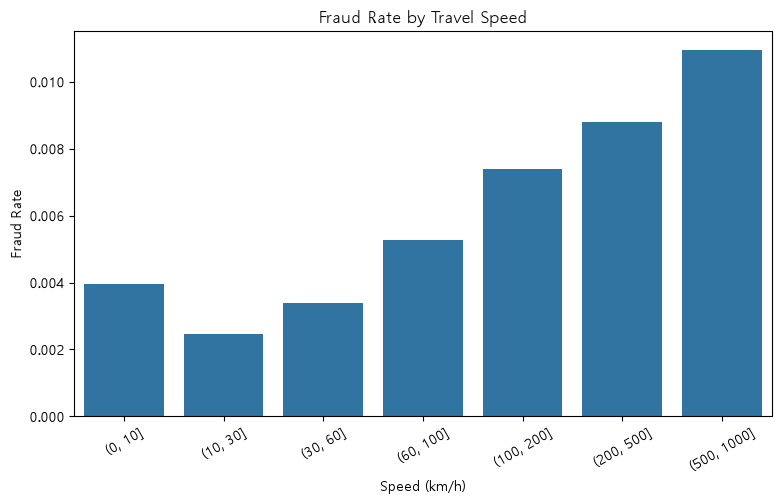

In [82]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=speed_fraud,
    x='speed_group',
    y='fraud_rate'
)

plt.title("Fraud Rate by Travel Speed")
plt.xlabel("Speed (km/h)")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=30)

plt.show()

In [83]:
offline_df['speed_kmh'] = offline_df['speed_kmh'].replace([np.inf, -np.inf], np.nan)

In [84]:
df['speed_kmh'].describe()

count    1.295672e+06
mean     1.891645e+02
std      3.798020e+03
min      3.682387e-03
25%      7.599863e+00
50%      2.001696e+01
75%      5.876701e+01
max      7.806232e+05
Name: speed_kmh, dtype: float64

In [85]:
speed_rate = (
    offline_df.groupby('speed_group', observed=False)
    .agg(
        transaction_count=('is_fraud','count'),
        fraud_count=('is_fraud','sum'),
        fraud_rate=('is_fraud','mean')
    )
    .reset_index()
)

speed_rate

,speed_group,transaction_count,fraud_count,fraud_rate
0,"(0, 10]",400680,1586,0.003958
1,"(10, 30]",322997,795,0.002461
2,"(30, 60]",160777,546,0.003396
3,"(60, 100]",85411,451,0.005280
4,"(100, 200]",76049,562,0.007390
5,"(200, 500]",51567,454,0.008804
6,"(500, 1000]",18255,200,0.010956


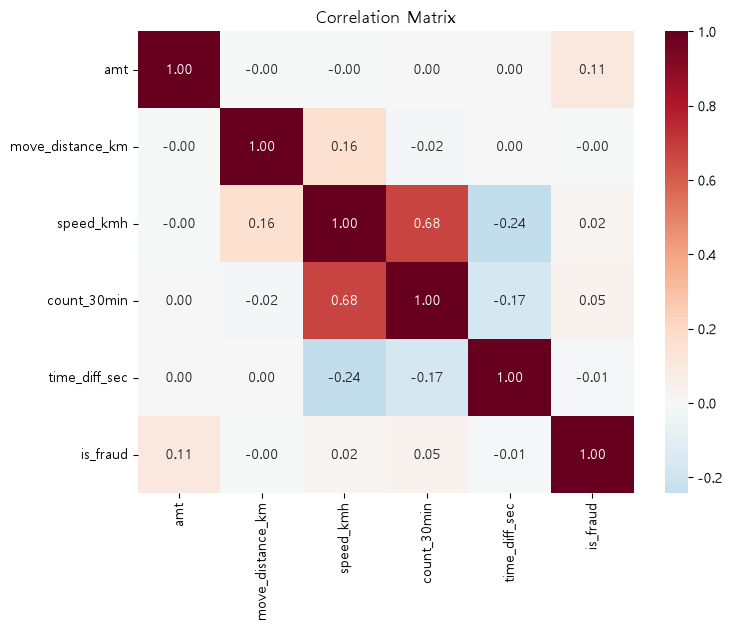

In [86]:
corr_df = offline_df.copy()

# inf 제거
corr_df = corr_df.replace([np.inf, -np.inf], np.nan)

# 극단치 제거(99%)
corr_df = corr_df[
    corr_df['speed_kmh'] <= corr_df['speed_kmh'].quantile(0.99)
]

corr = corr_df[
    [
        'amt',
        'move_distance_km',
        'speed_kmh',
        'count_30min',
        'time_diff_sec',
        'is_fraud'
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

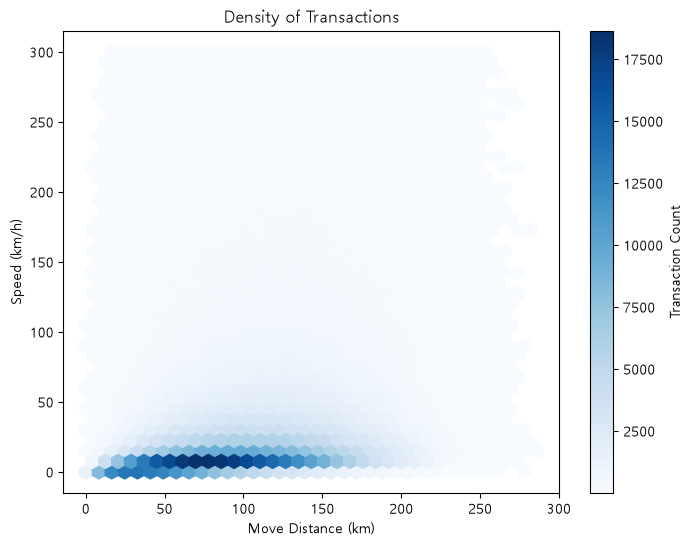

In [87]:
plot_df = offline_df.copy()

plot_df = plot_df.replace([np.inf,-np.inf],np.nan)

plot_df = plot_df[
    (plot_df['move_distance_km'] <= 500) &
    (plot_df['speed_kmh'] <= 300)
]

plt.figure(figsize=(8,6))

plt.hexbin(
    plot_df['move_distance_km'],
    plot_df['speed_kmh'],
    gridsize=35,
    cmap='Blues',
    mincnt=1
)

plt.colorbar(label='Transaction Count')

plt.xlabel("Move Distance (km)")
plt.ylabel("Speed (km/h)")
plt.title("Density of Transactions")

plt.show()

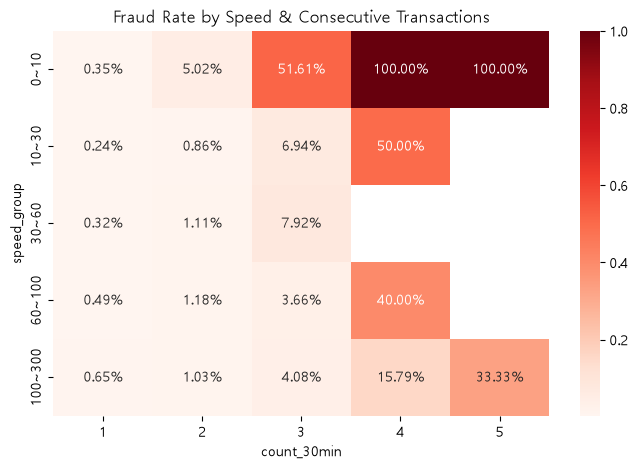

In [88]:
pivot = offline_df.copy()

pivot = pivot.replace([np.inf,-np.inf],np.nan)

pivot = pivot[
    pivot['speed_kmh']<=300
]

pivot['speed_group']=pd.cut(
    pivot['speed_kmh'],
    bins=[0,10,30,60,100,300],
    labels=['0~10','10~30','30~60','60~100','100~300']
)

table=pd.pivot_table(
    pivot,
    values='is_fraud',
    index='speed_group',
    columns='count_30min',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    table,
    annot=True,
    cmap='Reds',
    fmt='.2%'
)

plt.title("Fraud Rate by Speed & Consecutive Transactions")

plt.show()

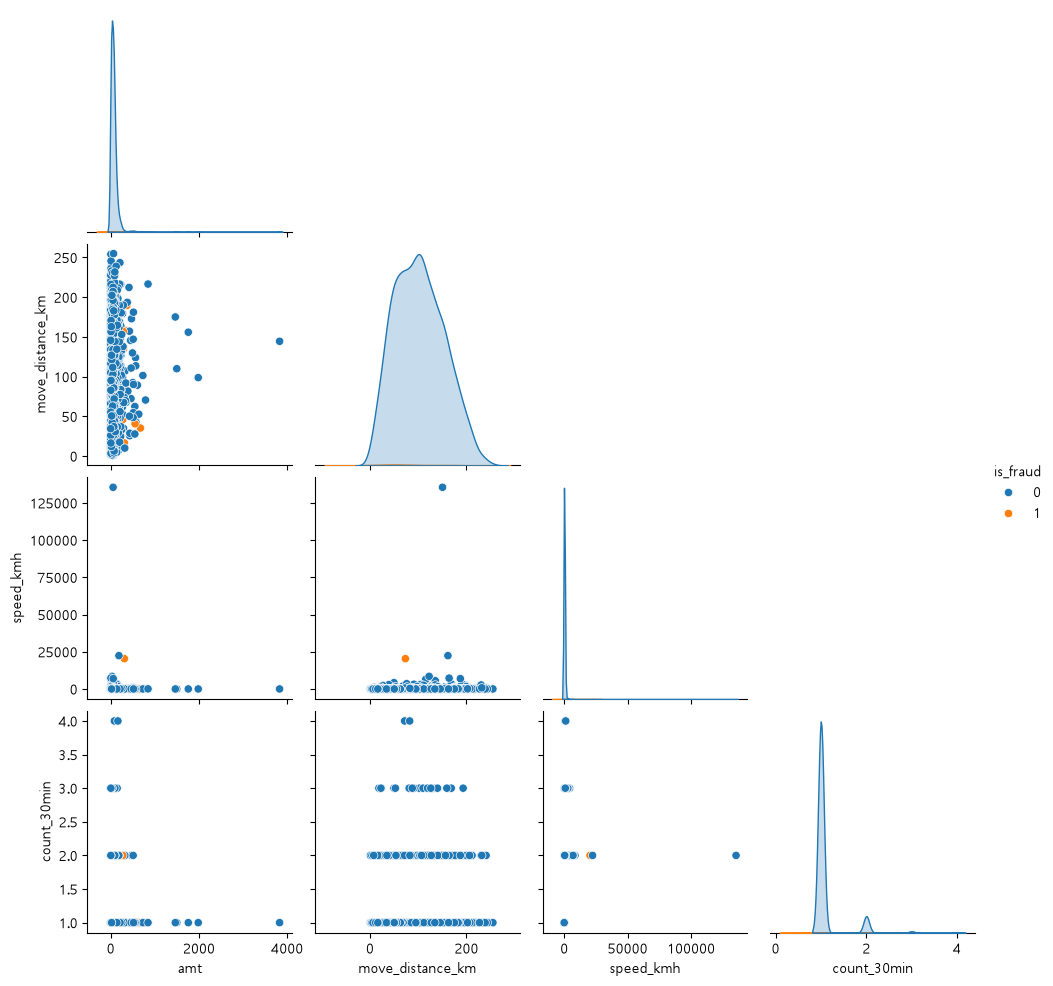

In [89]:
pair_df = offline_df.sample(3000, random_state=42)

sns.pairplot(
    pair_df[
        [
            'amt',
            'move_distance_km',
            'speed_kmh',
            'count_30min',
            'is_fraud'
        ]
    ],
    hue='is_fraud',
    corner=True
)

plt.show()

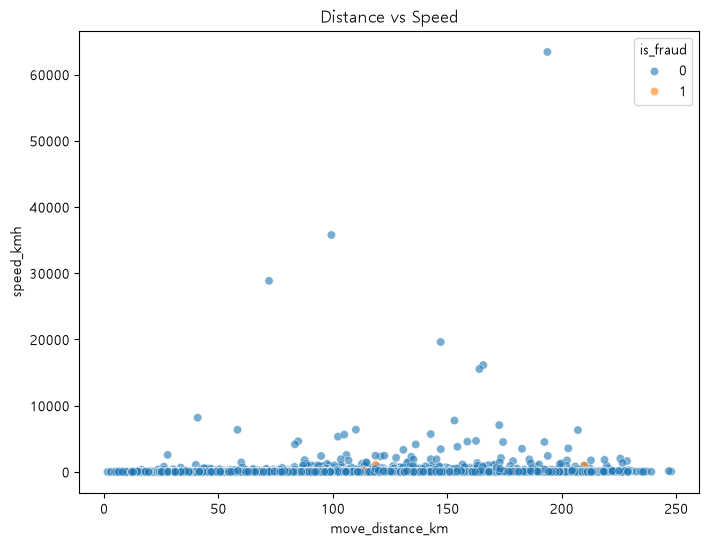

In [90]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=offline_df.sample(5000),
    x='move_distance_km',
    y='speed_kmh',
    hue='is_fraud',
    alpha=0.6
)

plt.title("Distance vs Speed")

plt.show()

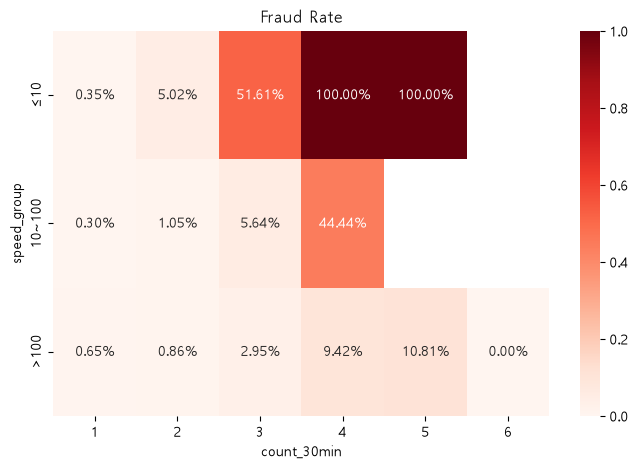

In [91]:
offline_df['speed_group'] = pd.cut(
    offline_df['speed_kmh'],
    bins=[0,10,100,np.inf],
    labels=['≤10','10~100','>100']
)

pivot = pd.pivot_table(
    offline_df,
    values='is_fraud',
    index='speed_group',
    columns='count_30min',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap='Reds',
    fmt='.2%'
)

plt.title("Fraud Rate")
plt.show()

In [92]:
speed_df = df.copy()

speed_df = speed_df.replace([np.inf, -np.inf], np.nan)

speed_df = speed_df.dropna(subset=['speed_kmh'])

speed_df = speed_df[speed_df['speed_kmh'] > 0]

In [93]:
df['speed_kmh'].describe()


count    1.295672e+06
mean     1.891645e+02
std      3.798020e+03
min      3.682387e-03
25%      7.599863e+00
50%      2.001696e+01
75%      5.876701e+01
max      7.806232e+05
Name: speed_kmh, dtype: float64

In [94]:

df[['time_diff_sec',
    'move_distance_km',
    'speed_kmh']].head(10)

,time_diff_sec,move_distance_km,speed_kmh
0,NaN,NaN,NaN
1,71862.0,224.769219,11.260043
2,159.0,105.220439,2382.349553
3,13838.0,88.152283,22.933099
4,1952.0,132.876773,245.059622
5,89149.0,112.505781,4.543190
6,11315.0,71.815290,22.848877
7,75285.0,85.440454,4.085616
8,26247.0,60.852335,8.346417
9,12302.0,146.839667,42.970476


In [95]:
df['speed_kmh'] = (
    df['move_distance_km']
    /
    (df['time_diff_sec']/3600)
)